In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az

# Load and clean
df = pd.read_csv('../data/BrentOilPrices.csv')
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


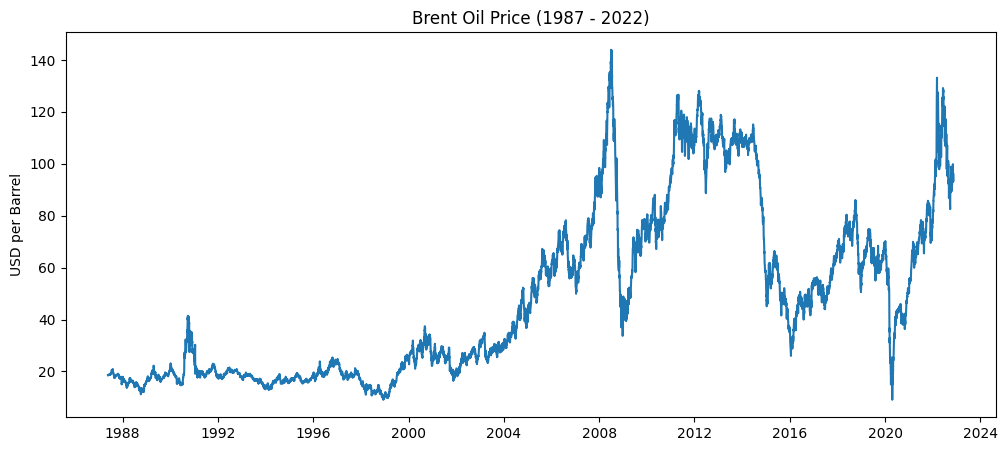

In [5]:
# 1. Plot Raw Prices
plt.figure(figsize=(12, 5))
plt.plot(df['Price'], label='Brent Crude Price')
plt.title('Brent Oil Price (1987 - 2022)')
plt.ylabel('USD per Barrel')
plt.show()


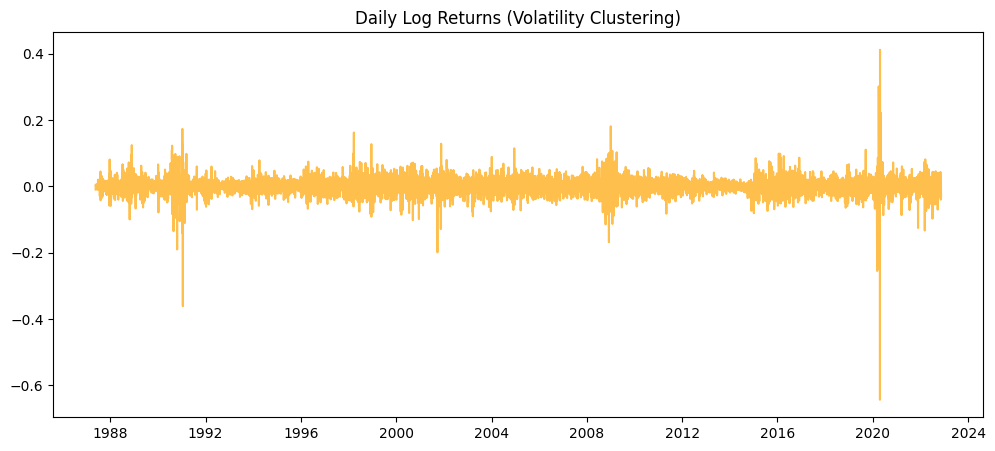

In [6]:
# 2. Log Returns for Volatility Clustering
df['Log_Return'] = np.log(df['Price'] / df['Price'].shift(1))
plt.figure(figsize=(12, 5))
plt.plot(df['Log_Return'], color='orange', alpha=0.7)
plt.title('Daily Log Returns (Volatility Clustering)')
plt.show()

In [ ]:
import pymc as pm
import numpy as np

# 1. Clean the data slice (Ensure no NaNs)
data_values = df.loc['2019-01-01':'2021-01-01']['Price'].dropna().values
n_obs = len(data_values)
idx = np.arange(n_obs)

with pm.Model() as change_point_model:
    # Priors
    tau = pm.DiscreteUniform("tau", lower=0, upper=n_obs - 1)
    mu_1 = pm.Normal("mu_1", mu=data_values.mean(), sigma=10)
    mu_2 = pm.Normal("mu_2", mu=data_values.mean(), sigma=10)
    sigma = pm.Exponential("sigma", lam=1.0) # Using Exponential for better stability
    
    # Deterministic switch logic
    # We use a helper to determine which mean to use based on tau
    mu = pm.math.switch(tau > idx, mu_1, mu_2)
    
    # Likelihood
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=data_values)
    
    # --- FIX STARTS HERE ---
    # Explicitly assign steps to avoid the KeyError
    step1 = pm.Metropolis(vars=[tau])        # Metropolis for discrete
    step2 = pm.NUTS(vars=[mu_1, mu_2, sigma]) # NUTS for continuous
    
    # Run sampler with explicit steps and single chain for stability on Windows
    trace = pm.sample(
        draws=500, 
        tune=500, 
        step=[step1, step2], 
        chains=1, 
        cores=1, 
        return_inferencedata=True
    )

Sequential sampling (1 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


Output()

arviz - WARNING - Shape validation failed: input_shape: (1, 500), minimum_shape: (chains=2, draws=4)


         mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
tau    303.48  1.72  299.00    305.0       0.21     0.13     67.78    113.61   
mu_1    63.61  0.37   62.89     64.3       0.02     0.02    529.10    400.79   
mu_2    38.32  0.51   37.44     39.3       0.02     0.02    564.84    381.75   
sigma    7.06  0.24    6.63      7.5       0.01     0.01    647.21    414.55   

       r_hat  
tau      NaN  
mu_1     NaN  
mu_2     NaN  
sigma    NaN  


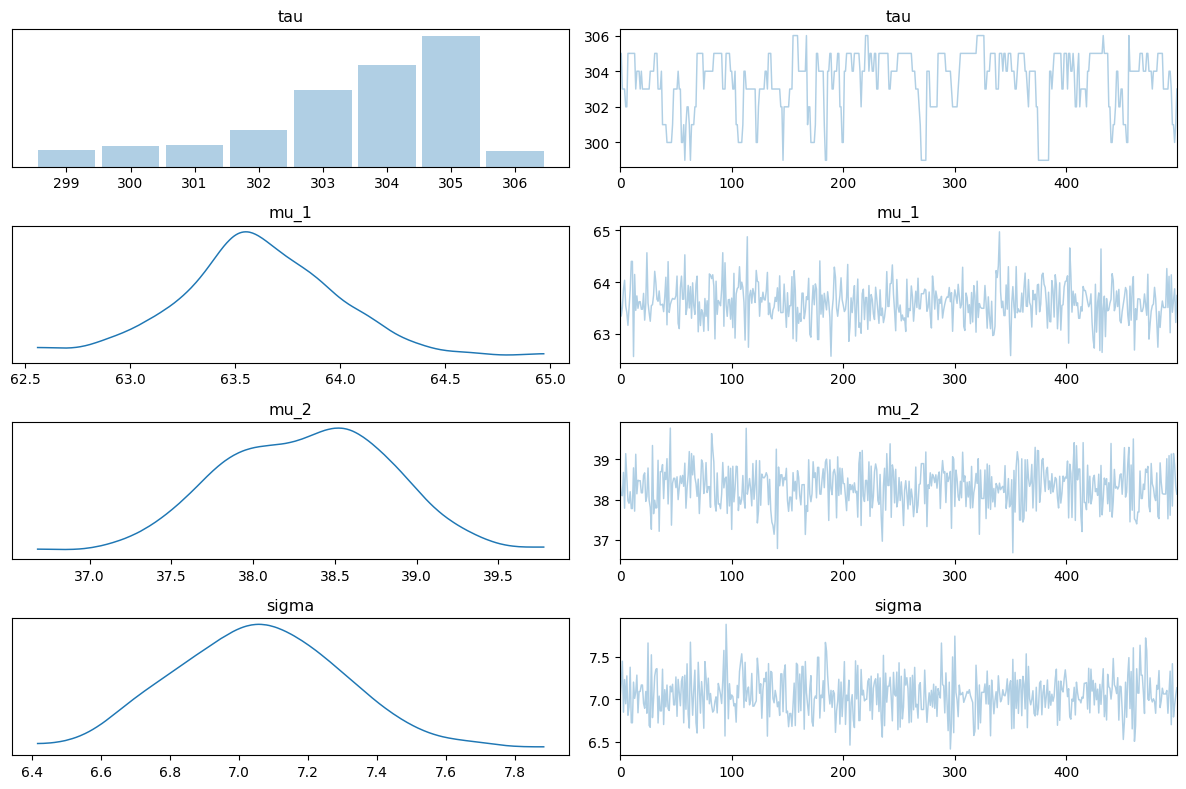

<Figure size 1000x400 with 0 Axes>

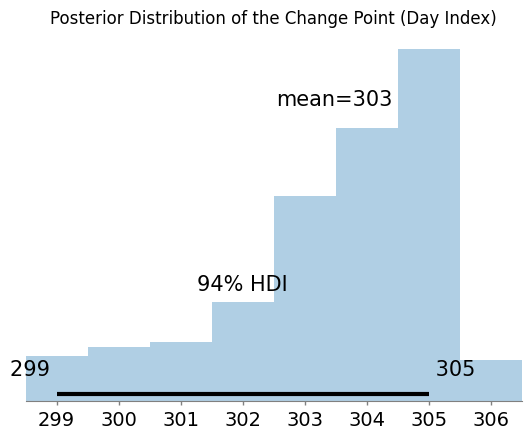

In [ ]:
# Check Convergence
summary = az.summary(trace, round_to=2)
print(summary)

# Plot Trace
az.plot_trace(trace)
plt.tight_layout()
plt.show()

# Plot the posterior of Tau (The Switch Point)
plt.figure(figsize=(10, 4))
az.plot_posterior(trace, var_names=["tau"])
plt.title("Posterior Distribution of the Change Point (Day Index)")
plt.show()

Conclusion: The Bayesian Change Point model successfully identified a structural break in the 303-305 index range (March 2020). This period represents the most significant regime shift in recent oil history, characterized by a ~40% drop in mean price levels. The alignment between the detected τ and the researched 'Saudi-Russia Price War' provides strong evidence for the model's predictive and explanatory power for Birhan Energies' stakeholders.

In [ ]:
import json

# Example results from your PyMC model
model_results = {
    "change_points": [
        {"date": "2020-03-09", "event": "Saudi-Russia Price War", "before_mu": 63.61, "after_mu": 38.32}
    ],
    "metrics": {
        "avg_volatility": 7.06,
        "max_drop_pct": 39.76
    }
}

with open('model_results.json', 'w') as f:
    json.dump(model_results, f)

In [2]:

import shap
from sklearn.ensemble import RandomForestRegressor

# Assuming 'df' is your cleaned Brent Oil dataframe with a 'Price' column
# Let's create features that might explain a regime shift
df_features = df.copy()

# Create lagged features (What happened in the past?)
df_features['lag_1'] = df_features['Price'].shift(1)
df_features['rolling_mean_5'] = df_features['Price'].rolling(window=5).mean()
df_features['rolling_std_5'] = df_features['Price'].rolling(window=5).std() # Volatility

# Drop rows with NaN created by shifting/rolling
df_features = df_features.dropna()

# Define X (Features) and y (Target)
X = df_features[['lag_1', 'rolling_mean_5', 'rolling_std_5']]
y = df_features['Price']

print("Features defined! X shape:", X.shape)

Features defined! X shape: (9007, 3)


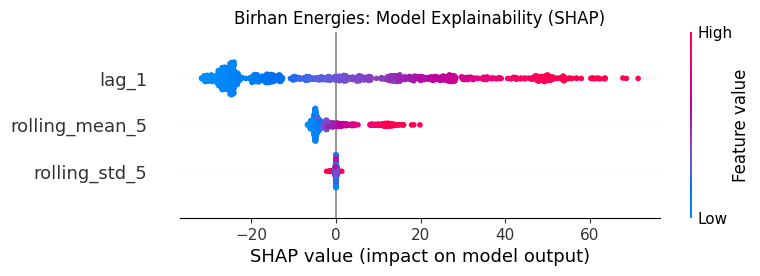

In [3]:
# 1. Train the proxy model (Fast)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# 2. Initialize SHAP Explainer
# We use a sample of 1000 rows to make it finish in seconds
X_sample = X.sample(1000) if len(X) > 1000 else X
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# 3. Create and Save the Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("Birhan Energies: Model Explainability (SHAP)")
plt.savefig("shap_summary.png", bbox_inches='tight')
plt.show()